Breast Cancer Diagnosis Project

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import joblib

Load Dataset

In [19]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)
print(X.head())

Dataset shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst 

Q7: Preprocessing


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Data split done. Train size:", X_train.shape, " Test size:", X_test.shape)

Data split done. Train size: (455, 30)  Test size: (114, 30)


Q2: How does KNN work?

In [21]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

#Q3: Accuracy, Precision, Recall

In [22]:
print("KNN Evaluation Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))

KNN Evaluation Metrics:
Accuracy: 0.9473684210526315
Precision: 0.9577464788732394
Recall: 0.9577464788732394
F1-score: 0.9577464788732394


Q4: How to choose K in KNN (Elbow Method)

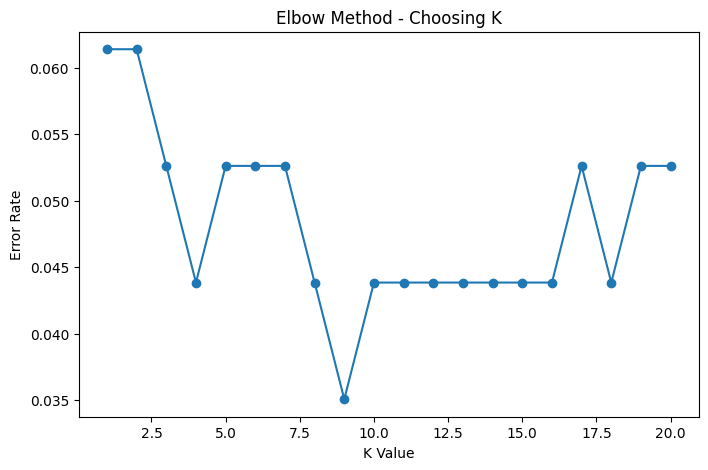

In [23]:
error_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), error_rate, marker='o')
plt.title('Elbow Method - Choosing K')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()


 #Q1 & Q11: What features are most predictive? (Feature Importance)
 ---------------------------
 Logistic Regression gives coefficients

                 Feature  Coefficient
21         worst texture     1.357512
10          radius error     1.250573
28        worst symmetry     1.195597
7    mean concave points     1.107711
26       worst concavity     0.951686
13            area error     0.919877
20          worst radius     0.873944
23            worst area     0.838030
6         mean concavity     0.807676
27  worst concave points     0.780408


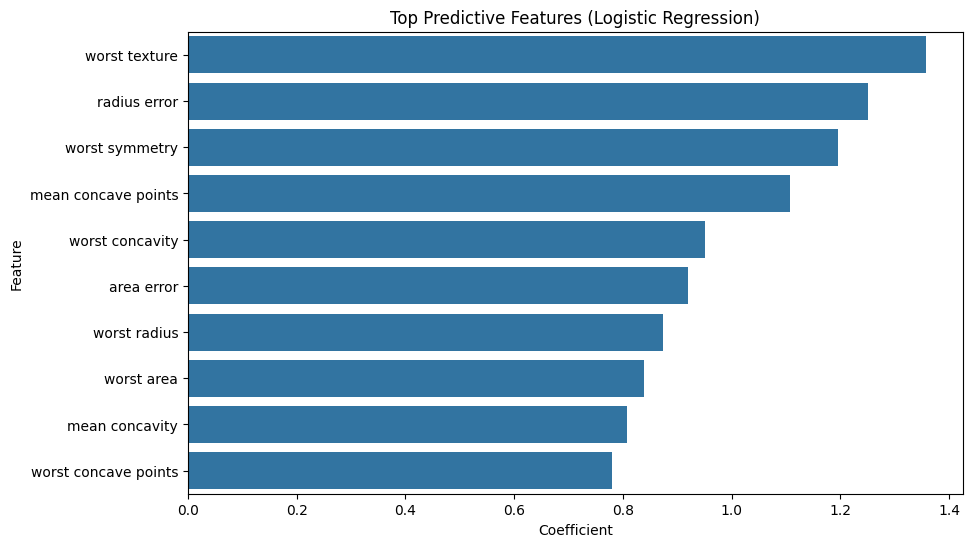

In [24]:
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': abs(log_reg.coef_[0])
}).sort_values(by='Coefficient', ascending=False)
print(feature_importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10))
plt.title("Top Predictive Features (Logistic Regression)")
plt.show()


 Q5: What is ROC-AUC?

ROC-AUC Score: 0.99737962659679


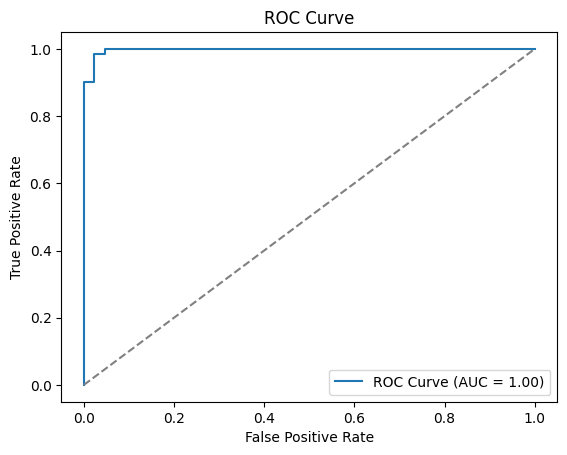

In [25]:
y_proba = log_reg.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Q6: Handling Imbalanced Data

In [26]:
print("Class Distribution:", y.value_counts())
# For imbalanced data, you can use SMOTE or class_weight (not needed here since balanced dataset)

Class Distribution: 1    357
0    212
Name: count, dtype: int64


Q8: Visualize Decision Boundaries (2D PCA)

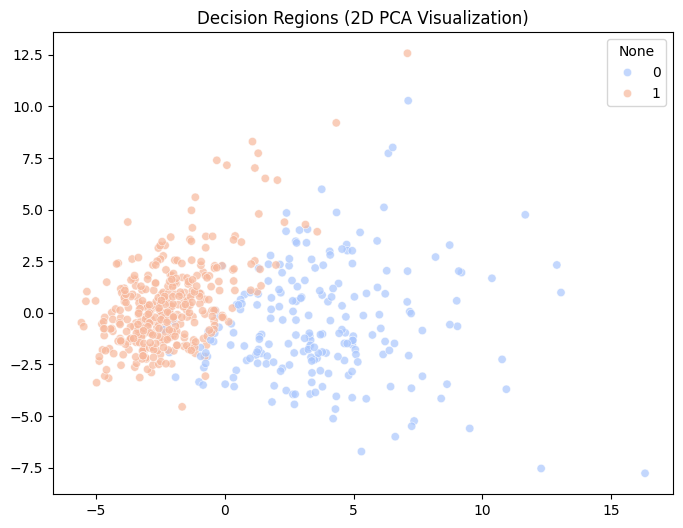

In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_reduced, y)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=y, palette='coolwarm', alpha=0.7)
plt.title('Decision Regions (2D PCA Visualization)')
plt.show()

Q9: What is Overfitting?

In [28]:
# Train a new KNN model on the original training data
knn_full = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as in the earlier KNN example
knn_full.fit(X_train, y_train)

train_acc = knn_full.score(X_train, y_train)
test_acc = knn_full.score(X_test, y_test)
print(f"Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")
print("If Train >> Test, overfitting is present.")

Train Accuracy: 0.98, Test Accuracy: 0.95
If Train >> Test, overfitting is present.


Q10: How to Compare Models (KNN vs Logistic Regression)

In [29]:
# Re-generate KNN predictions in this cell for comparison
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

y_pred_lr = log_reg.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

KNN Accuracy: 0.9473684210526315
Logistic Regression Accuracy: 0.9736842105263158


Q12: Normalize or Scale Data (already done)

In [30]:
print("Data scaling completed using StandardScaler.")


Data scaling completed using StandardScaler.


Q13: Hyperparameter Tuning with GridSearchCV

In [31]:
param_grid = {'n_neighbors': [3,5,7,9,11]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print("Best K from GridSearch:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best K from GridSearch: {'n_neighbors': 5}
Best Score: 0.9604395604395606


Q14: Confusion Matrix & ROC Curve

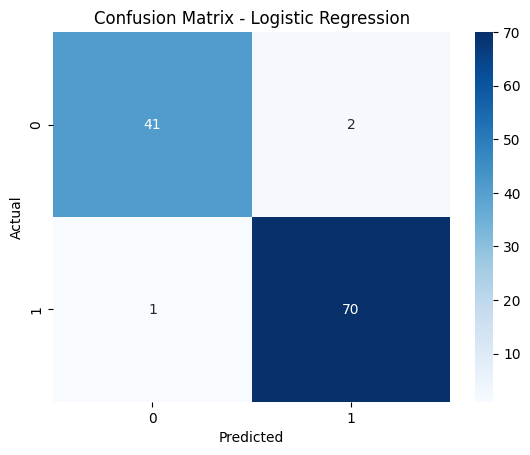

In [32]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Q15: Save and Reload Model

In [33]:
joblib.dump(log_reg, 'breast_cancer_model.pkl')
loaded_model = joblib.load('breast_cancer_model.pkl')
sample_pred = loaded_model.predict([X_test[0]])
print("Sample Prediction after Reloading:", sample_pred)

Sample Prediction after Reloading: [1]
